# 🔥 Grad-CAM Visualization — DualMultiBranch_CNN
Loads `fixed_model.keras` directly — no retraining needed.

## Cell 1 — Imports

In [1]:
import os, random, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm_module
import cv2
from PIL import Image
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.applications import (ResNet50, EfficientNetB0,
                                            Xception, DenseNet121)
from tensorflow.keras.layers import (Input, Dense, GlobalAveragePooling2D,
                                      Dropout, Concatenate, BatchNormalization)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)
plt.rcParams.update({'figure.dpi': 120})

print(f'TensorFlow: {tf.__version__}')
print('✅ Imports done')

TensorFlow: 2.19.0
✅ Imports done


## Cell 2 — Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')
print('✅ Drive mounted')

Mounted at /content/drive
✅ Drive mounted


## Cell 3 — Configuration

In [10]:
# ── Paths ──────────────────────────────────────────────────────────────
MODEL_PATH  = '/content/drive/MyDrive/lung_colon_outputs/final_combined_model.keras'
DATASET_DIR = '/content/drive/MyDrive/dataset.zip'   # folder containing 5 class subfolders
SAVE_DIR    = '/content/drive/MyDrive/gradcam_outputs'

# ── Settings ───────────────────────────────────────────────────────────
IMG_SIZE      = (224, 224)
N_SAMPLES     = 2        # images per class in the main grid
ALPHA         = 0.45     # heatmap overlay transparency
SAVE_FIGURES  = True     # set False to skip saving to Drive

# ── Class info ─────────────────────────────────────────────────────────
CLASS_NAMES = ['colon_aca', 'colon_n', 'lung_aca', 'lung_n', 'lung_scc']
CLASS_LABELS = {
    'colon_aca' : 'Colon Adenocarcinoma',
    'colon_n'   : 'Colon Benign',
    'lung_aca'  : 'Lung Adenocarcinoma',
    'lung_n'    : 'Lung Benign',
    'lung_scc'  : 'Lung Squamous Cell Carcinoma'
}
IMG_EXT = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff')

os.makedirs(SAVE_DIR, exist_ok=True)
print('✅ Config ready')
print(f'   Model      : {MODEL_PATH}')
print(f'   Dataset    : {DATASET_DIR}')
print(f'   Save dir   : {SAVE_DIR}')

✅ Config ready
   Model      : /content/drive/MyDrive/lung_colon_outputs/final_combined_model.keras
   Dataset    : /content/drive/MyDrive/dataset.zip
   Save dir   : /content/drive/MyDrive/gradcam_outputs


## Cell 4 — Load Model
Tries `load_model` first (works if saved with `model.save()`).  
Falls back to rebuild architecture + `load_weights` automatically.

In [11]:
def build_combined_model(num_classes=5, img_shape=(224, 224, 3),
                          dropout=0.5, lr=1e-4):
    """Exact same architecture used during training."""
    inputs = Input(shape=img_shape, name='shared_input')

    def frozen_branch(backbone_cls, prefix, backbone_name):
        base = backbone_cls(weights=None, include_top=False,
                            input_shape=img_shape, name=backbone_name)
        base.trainable = False
        for layer in base.layers:
            layer._name = f'{prefix}_{layer.name}'
        x = base(inputs, training=False)
        x = GlobalAveragePooling2D(name=f'{prefix}_gap')(x)
        return x

    # Dual-Branch
    d_resnet    = frozen_branch(ResNet50,       'dual_resnet',    'dual_resnet_backbone')
    d_efficient = frozen_branch(EfficientNetB0, 'dual_efficient', 'dual_efficientnet_backbone')
    dual_fused  = Concatenate(name='dual_feature_fusion')([d_resnet, d_efficient])

    # Multi-Branch
    m_resnet    = frozen_branch(ResNet50,    'multi_resnet',   'multi_resnet_backbone')
    m_xception  = frozen_branch(Xception,    'multi_xception', 'multi_xception_backbone')
    m_densenet  = frozen_branch(DenseNet121, 'multi_densenet', 'multi_densenet_backbone')
    multi_fused = Concatenate(name='multi_feature_fusion')([m_resnet, m_xception, m_densenet])

    # Global Fusion
    global_fused = Concatenate(name='global_feature_fusion')([dual_fused, multi_fused])

    # Classifier Head
    x   = Dense(1024, activation='relu', name='fc1')(global_fused)
    x   = BatchNormalization(name='bn1')(x)
    x   = Dropout(dropout, name='drop1')(x)
    x   = Dense(512, activation='relu', name='fc2')(x)
    x   = BatchNormalization(name='bn2')(x)
    x   = Dropout(dropout / 2, name='drop2')(x)
    out = Dense(num_classes, activation='softmax', name='softmax_output')(x)

    m = Model(inputs=inputs, outputs=out, name='DualMultiBranch_CNN')
    m.compile(optimizer=Adam(lr), loss='categorical_crossentropy',
              metrics=['accuracy'])
    return m


# ── Try load_model first, fall back to load_weights ────────────────────
print(f'Loading: {MODEL_PATH}')
try:
    model = load_model(MODEL_PATH, compile=False)
    print('✅ Loaded with load_model()')
except Exception as e:
    print(f'load_model failed ({e})')
    print('Rebuilding architecture and loading weights...')
    model = build_combined_model()
    model.load_weights(MODEL_PATH)
    print('✅ Loaded with load_weights()')

print(f'   Total params : {model.count_params():,}')

# Sanity check
dummy = np.zeros((1, 224, 224, 3), dtype='float32')
out   = model.predict(dummy, verbose=0)
print(f'   Output shape : {out.shape}   <- should be (1, 5)')
print(f'   Probs sum    : {out.sum():.4f}  <- should be ~1.0')

Loading: /content/drive/MyDrive/lung_colon_outputs/final_combined_model.keras
✅ Loaded with load_model()
   Total params : 88,309,264
   Output shape : (1, 5)   <- should be (1, 5)
   Probs sum    : 1.0000  <- should be ~1.0


## Cell 5 — Auto-detect Best Grad-CAM Layer

In [12]:
def find_gradcam_layer(model, preferred_prefix='multi_resnet'):
    """
    Finds the last conv layer inside backbone sub-models.
    Prefers multi_resnet_backbone (ResNet50 gives cleanest heatmaps).
    Returns (layer_name, sub_model_or_None).
    """
    # Priority 1: preferred backbone
    for layer in model.layers:
        if hasattr(layer, 'layers') and preferred_prefix in layer.name:
            for sub in reversed(layer.layers):
                if ('conv' in sub.name.lower() and
                        not isinstance(sub, tf.keras.layers.DepthwiseConv2D)):
                    print(f'  Found in [{layer.name}] -> {sub.name}')
                    return sub.name, layer

    # Priority 2: any backbone sub-model
    for layer in model.layers:
        if hasattr(layer, 'layers') and 'backbone' in layer.name:
            for sub in reversed(layer.layers):
                if 'conv' in sub.name.lower():
                    print(f'  Fallback [{layer.name}] -> {sub.name}')
                    return sub.name, layer

    # Priority 3: top-level conv
    for layer in reversed(model.layers):
        if 'conv' in layer.name.lower():
            print(f'  Top-level fallback -> {layer.name}')
            return layer.name, None

    raise ValueError('No conv layer found — check model architecture')


print('Scanning for best Grad-CAM layer...')
GRADCAM_LAYER, GRADCAM_SUBMODEL = find_gradcam_layer(model)
print(f'\n✅ Grad-CAM layer  : {GRADCAM_LAYER}')
if GRADCAM_SUBMODEL is not None:
    print(f'   Inside sub-model : {GRADCAM_SUBMODEL.name}')

Scanning for best Grad-CAM layer...
  Found in [multi_resnet_backbone] -> conv5_block3_out

✅ Grad-CAM layer  : conv5_block3_out
   Inside sub-model : multi_resnet_backbone


## Cell 6 — Grad-CAM Core Functions

In [29]:
def get_gradcam_heatmap(model, img_array, sub_model, conv_layer_name, pred_index=None):
    """
    Compute Grad-CAM heatmap.

    Parameters
    ----------
    model           : full Keras model
    img_array       : float32 array shape (1, 224, 224, 3), values in [0, 1]
    sub_model       : backbone sub-model containing the conv layer (or None)
    conv_layer_name : name of target conv layer
    pred_index      : class index to explain; None = top predicted class

    Returns
    -------
    heatmap    : float32 array (H, W), values in [0, 1]
    pred_index : int
    probs      : float32 array (5,)
    """
    if sub_model is not None:
        # The conv layer is inside a sub-model (e.g., ResNet50 backbone).
        # We need to create an intermediate model that takes the sub_model's original input
        # and outputs the specified conv layer's activations.
        intermediate_extractor_model = tf.keras.models.Model(
            inputs=sub_model.inputs,
            outputs=sub_model.get_layer(conv_layer_name).output
        )

        # Now, build the main grad_model:
        # Its input is the overall model's input (the image).
        # Its first output is the conv feature map, obtained by feeding the image into our extractor.
        # Its second output is the overall model's final prediction.
        grad_model = tf.keras.models.Model(
            inputs=model.inputs,
            outputs=[
                intermediate_extractor_model(model.inputs[0]),
                model.output
            ]
        )
    else:
        # This case is for when conv_layer_name is a direct layer of the main model
        grad_model = tf.keras.models.Model(
            inputs  = model.inputs,
            outputs = [model.get_layer(conv_layer_name).output, model.output]
        )

    img_tensor = tf.cast(img_array, tf.float32)

    with tf.GradientTape() as tape:
        # We need to watch the input to the grad_model to ensure all operations are tracked
        # and explicitly watch conv_outputs as we need gradients w.r.t this intermediate tensor.
        tape.watch(img_tensor)
        conv_outputs, predictions = grad_model(img_tensor, training=False)
        tape.watch(conv_outputs) # Explicitly watch the convolutional layer's output
        if pred_index is None:
            pred_index = int(tf.argmax(predictions[0]))
        class_score = predictions[:, pred_index]

    grads    = tape.gradient(class_score, conv_outputs)   # (1, H, W, C)
    pooled   = tf.reduce_mean(grads, axis=(0, 1, 2))      # (C,)
    conv_out = conv_outputs[0]                            # (H, W, C)
    heatmap  = conv_out @ pooled[..., tf.newaxis]         # (H, W, 1)
    heatmap  = tf.squeeze(heatmap)                        # (H, W)
    heatmap  = tf.nn.relu(heatmap)                        # only positive activations
    heatmap  = heatmap / (tf.reduce_max(heatmap) + 1e-8) # normalize to [0, 1]

    return heatmap.numpy(), pred_index, predictions[0].numpy()


def make_overlay(img_path, heatmap, alpha=0.45):
    """Returns (original_rgb, heatmap_colored_rgb, overlay_rgb) as uint8."""
    orig         = np.array(Image.open(img_path).convert('RGB').resize((224, 224)))
    h_uint8      = np.uint8(255 * cv2.resize(heatmap, (224, 224)))
    colormap     = cm_module.get_cmap('jet')
    heat_colored = np.uint8(colormap(h_uint8 / 255.0)[..., :3] * 255)
    overlay      = np.uint8(orig * (1 - alpha) + heat_colored * alpha)
    return orig, heat_colored, overlay


def load_image(img_path):
    """Returns (PIL image, model-ready numpy array)."""
    img = Image.open(img_path).convert('RGB').resize(IMG_SIZE)
    arr = np.expand_dims(np.array(img) / 255.0, axis=0).astype('float32')
    return img, arr


print('✅ Grad-CAM functions defined')

✅ Grad-CAM functions defined


## Cell 7 — Verify Dataset Folders

In [23]:
import zipfile
import os

# Original DATASET_DIR from Cell 3 points to a zip file.
original_zip_path = DATASET_DIR
extracted_dataset_root = '/content'

# Check if the zip file exists and the target extraction directory doesn't already contain the class folders
# This prevents unnecessary re-extraction if a previous run already extracted it
if os.path.isfile(original_zip_path) and original_zip_path.endswith('.zip'):
    # Updated heuristic: check for the *intermediate* folders like colon_image_sets
    if not (os.path.isdir(os.path.join(extracted_dataset_root, 'colon_image_sets')) or \
            os.path.isdir(os.path.join(extracted_dataset_root, 'lung_image_sets'))):
        print(f"Extracting {original_zip_path} to {extracted_dataset_root}...")
        try:
            with zipfile.ZipFile(original_zip_path, 'r') as zip_ref:
                zip_ref.extractall(extracted_dataset_root)
            print("Extraction complete.")
        except zipfile.BadZipFile:
            print(f"Error: {original_zip_path} is not a valid zip file.")
            # Do not proceed with path change if extraction failed
            # This will cause an error in subsequent steps, which is desired.
        except Exception as e:
            print(f"An unexpected error occurred during extraction: {e}")
            # This will cause an error in subsequent steps, which is desired.

# Now, based on the `os.listdir('/content')` output, the actual class folders are nested.
# We need to construct the full paths for each class
class_directories = {} # Will map class_name -> full_path_to_class_folder

for class_name in CLASS_NAMES:
    base_image_set_dir = None
    if class_name.startswith('colon'):
        base_image_set_dir = os.path.join(extracted_dataset_root, 'colon_image_sets')
    elif class_name.startswith('lung'):
        base_image_set_dir = os.path.join(extracted_dataset_root, 'lung_image_sets')
    else:
        continue # Should not happen with current CLASS_NAMES

    if base_image_set_dir and os.path.isdir(base_image_set_dir):
        full_class_path = os.path.join(base_image_set_dir, class_name)
        if os.path.isdir(full_class_path):
            class_directories[class_name] = full_class_path

available_classes = sorted(list(class_directories.keys())) # List of class names actually found

print(f'Found {len(available_classes)}/{len(CLASS_NAMES)} class folders:')
for cls in available_classes:
    n = len([f for f in os.listdir(class_directories[cls]) # Use the dynamically determined path
             if f.lower().endswith(IMG_EXT)])
    print(f'  {cls:12s} — {n:,} images')

assert len(available_classes) == 5, \
    f'Only {len(available_classes)} found. Check dataset structure and CLASS_NAMES.'

Found 5/5 class folders:
  colon_aca    — 5,000 images
  colon_n      — 5,000 images
  lung_aca     — 5,000 images
  lung_n       — 5,000 images
  lung_scc     — 5,000 images


In [24]:
import os
print(os.listdir('/content'))
# Alternatively, use a shell command to see more detail:
# !ls -F /content

['.config', 'drive', 'colon_image_sets', 'lung_image_sets', 'sample_data']


## Cell 8 — Main Grad-CAM Grid
**5 classes x 2 samples x 3 panels** (Original | Heatmap | Overlay)  
This is Figure 9 for your report.

✅ Saved -> /content/drive/MyDrive/gradcam_outputs/gradcam_grid_all_classes.png


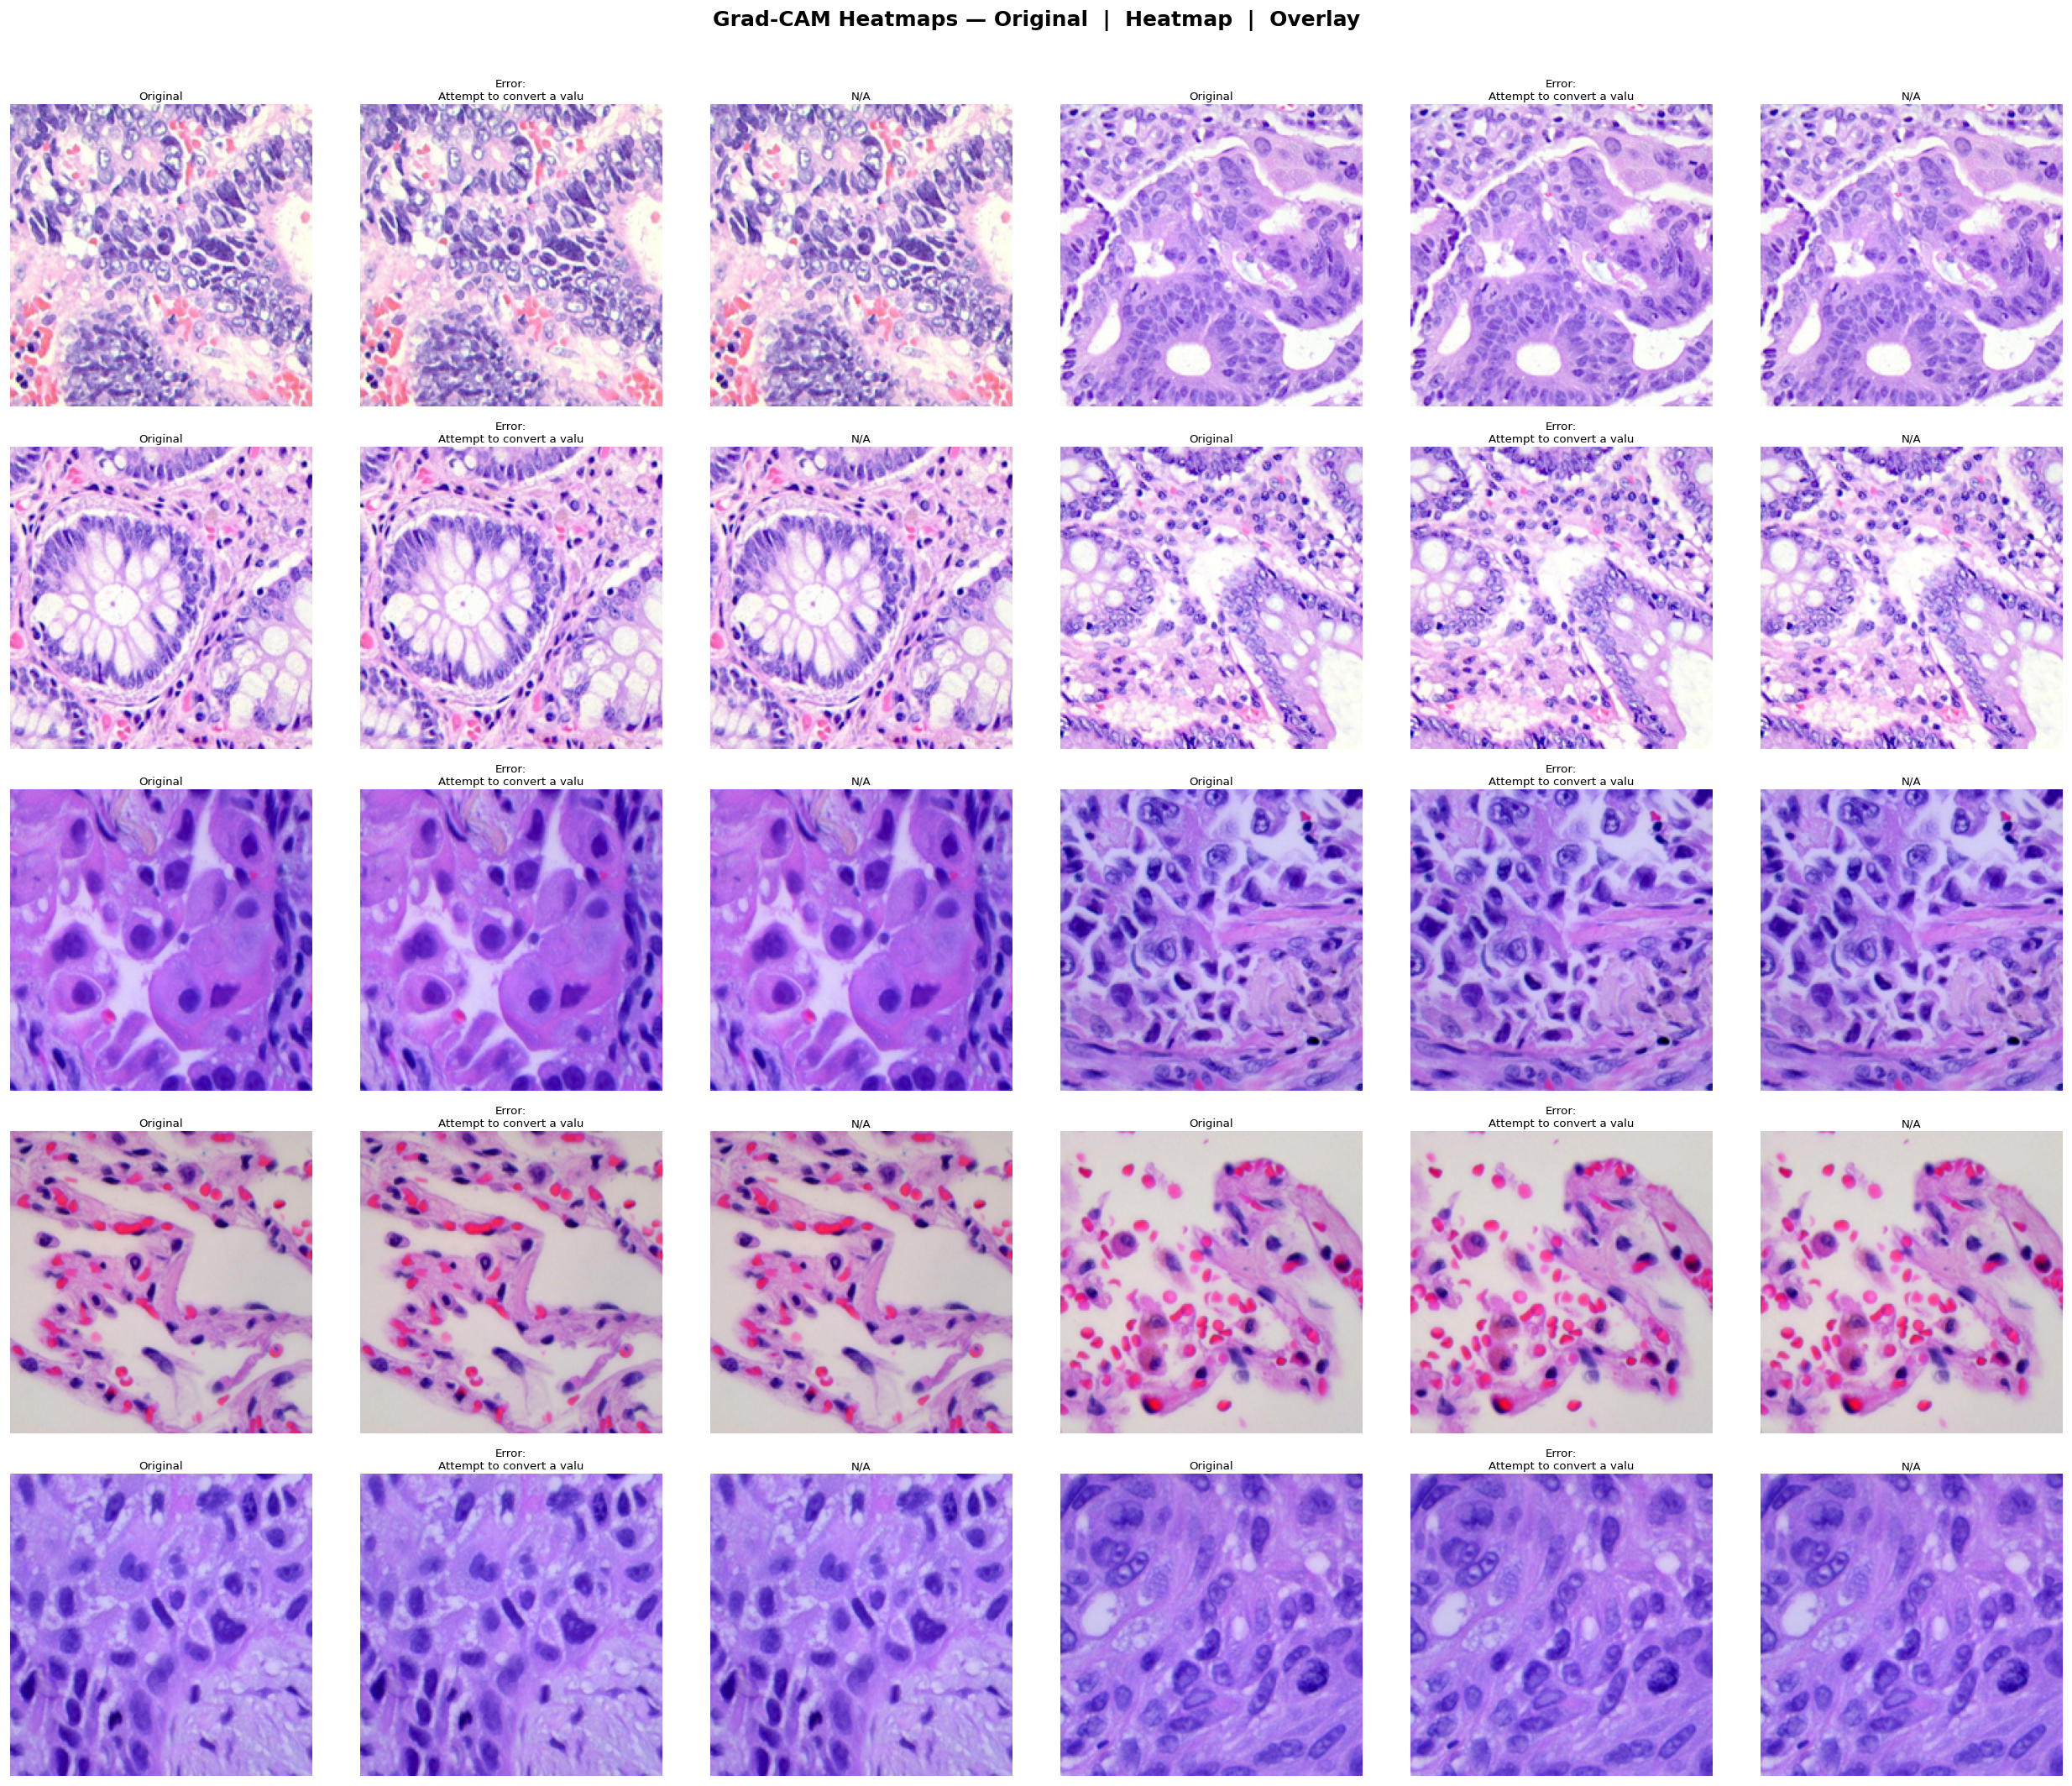

✅ Grid complete


In [25]:
COLS      = N_SAMPLES * 3
ROWS      = len(available_classes)
fig, axes = plt.subplots(ROWS, COLS, figsize=(COLS * 3.5, ROWS * 3.5))
fig.suptitle(
    'Grad-CAM Heatmaps — Original  |  Heatmap  |  Overlay',
    fontsize=15, fontweight='bold', y=1.01
)

for row, cls in enumerate(available_classes):
    # Updated to use class_directories for the correct path
    cls_dir  = class_directories[cls]
    all_imgs = [f for f in os.listdir(cls_dir) if f.lower().endswith(IMG_EXT)]
    samples  = random.sample(all_imgs, min(N_SAMPLES, len(all_imgs)))

    for s_idx, img_name in enumerate(samples):
        img_path   = os.path.join(cls_dir, img_name)
        _, img_arr = load_image(img_path)

        try:
            heatmap, pred_idx, probs = get_gradcam_heatmap(
                model, img_arr, GRADCAM_SUBMODEL, GRADCAM_LAYER
            )
            orig, heat_colored, overlay = make_overlay(img_path, heatmap, ALPHA)
            pred_cls   = available_classes[pred_idx] if pred_idx < len(available_classes) else str(pred_idx)
            confidence = probs[pred_idx] * 100
            visuals = [orig, heat_colored, overlay]
            titles  = [
                'Original',
                'Grad-CAM',
                f'Overlay\n(pred: {pred_cls}\n{confidence:.1f}%)'
            ]
        except Exception as e:
            pil_img, _ = load_image(img_path)
            visuals = [np.array(pil_img)] * 3
            titles  = ['Original', f'Error:\n{str(e)[:25]}', 'N/A']

        base_col = s_idx * 3
        for v_idx, (vis, title) in enumerate(zip(visuals, titles)):
            ax = axes[row, base_col + v_idx]
            ax.imshow(vis)
            ax.axis('off')
            ax.set_title(title, fontsize=8, pad=3)

    axes[row, 0].set_ylabel(
        CLASS_LABELS.get(cls, cls),
        fontsize=10, fontweight='bold',
        rotation=0, labelpad=140, va='center'
    )

plt.tight_layout()

if SAVE_FIGURES:
    sp = os.path.join(SAVE_DIR, 'gradcam_grid_all_classes.png')
    plt.savefig(sp, dpi=150, bbox_inches='tight')
    print(f'✅ Saved -> {sp}')

plt.show()
print('✅ Grid complete')

## Cell 9 — Single Image: 4-Panel View
Original | Grad-CAM | Overlay | Confidence bars

In [30]:
def predict_with_gradcam(img_path, model, class_names, sub_model,
                          conv_layer_name, alpha=0.45, save_dir=None):
    _, img_arr = load_image(img_path)
    heatmap, pred_idx, probs = get_gradcam_heatmap(
        model, img_arr, sub_model, conv_layer_name
    )
    orig, heat_colored, overlay = make_overlay(img_path, heatmap, alpha)

    pred_label = class_names[pred_idx]
    full_label = CLASS_LABELS.get(pred_label, pred_label)
    confidence = probs[pred_idx] * 100

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle(
        f'Prediction: {full_label}  ({confidence:.1f}% confidence)',
        fontsize=13, fontweight='bold', color='darkgreen'
    )

    # Panel 1 — Original
    axes[0].imshow(orig)
    axes[0].set_title('Original Image', fontweight='bold')
    axes[0].axis('off')

    # Panel 2 — Heatmap
    axes[1].imshow(heat_colored)
    axes[1].set_title('Grad-CAM Heatmap', fontweight='bold')
    axes[1].axis('off')

    # Panel 3 — Overlay
    axes[2].imshow(overlay)
    axes[2].set_title('Overlay', fontweight='bold')
    axes[2].axis('off')

    # Panel 4 — Confidence bars
    bar_colors  = ['#C44E52' if i == pred_idx else '#AEC6CF'
                   for i in range(len(class_names))]
    full_labels = [CLASS_LABELS.get(c, c) for c in class_names]
    axes[3].barh(full_labels, probs * 100, color=bar_colors, edgecolor='white')
    axes[3].set_xlabel('Confidence (%)')
    axes[3].set_xlim(0, 115)
    axes[3].set_title('Class Probabilities', fontweight='bold')
    axes[3].invert_yaxis()
    for i, v in enumerate(probs * 100):
        axes[3].text(v + 1, i, f'{v:.1f}%', va='center', fontsize=9)
    axes[3].grid(axis='x', alpha=0.3)

    plt.tight_layout()

    if save_dir:
        fname = os.path.splitext(os.path.basename(img_path))[0]
        sp    = os.path.join(save_dir, f'gradcam_single_{fname}.png')
        plt.savefig(sp, dpi=150, bbox_inches='tight')
        print(f'   Saved -> {sp}')

    plt.show()
    return pred_label, confidence


# ── Pick a random test image (or replace TEST_IMG with your own path) ──
sample_cls = random.choice(available_classes)
# Updated to use class_directories for the correct path
sample_dir = class_directories[sample_cls]
TEST_IMG   = os.path.join(
    sample_dir,
    random.choice([f for f in os.listdir(sample_dir) if f.lower().endswith(IMG_EXT)])
)

print(f'Image : {TEST_IMG}')
pred_cls, conf = predict_with_gradcam(
    TEST_IMG, model,
    class_names     = available_classes,
    sub_model       = GRADCAM_SUBMODEL,
    conv_layer_name = GRADCAM_LAYER,
    alpha           = ALPHA,
    save_dir        = SAVE_DIR if SAVE_FIGURES else None
)
print(f'\n✅ Predicted : {pred_cls}')
print(f'   Confidence: {conf:.2f}%')

Image : /content/lung_image_sets/lung_scc/lungscc1462.jpeg


ValueError: Attempt to convert a value (None) with an unsupported type (<class 'NoneType'>) to a Tensor.

## Cell 10 — Save One Grad-CAM PNG per Class
Saves individual 3-panel figures to Drive — paste directly into your report.

In [20]:
print('Saving one Grad-CAM per class...\n')

for cls in available_classes:
    # Updated to use class_directories for the correct path
    cls_dir  = class_directories[cls]
    all_imgs = [f for f in os.listdir(cls_dir) if f.lower().endswith(IMG_EXT)]
    img_path = os.path.join(cls_dir, random.choice(all_imgs))
    _, img_arr = load_image(img_path)

    try:
        heatmap, pred_idx, probs = get_gradcam_heatmap(
            model, img_arr, GRADCAM_SUBMODEL, GRADCAM_LAYER
        )
        orig, heat_colored, overlay = make_overlay(img_path, heatmap, ALPHA)

        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        fig.suptitle(
            f'{CLASS_LABELS.get(cls, cls)}',
            fontsize=12, fontweight='bold'
        )
        for ax, vis, title in zip(
            axes,
            [orig, heat_colored, overlay],
            ['Original', 'Grad-CAM', 'Overlay']
        ):
            ax.imshow(vis)
            ax.axis('off')
            ax.set_title(title, fontsize=9)

        plt.tight_layout()

        if SAVE_FIGURES:
            sp = os.path.join(SAVE_DIR, f'gradcam_{cls}.png')
            plt.savefig(sp, dpi=150, bbox_inches='tight')
            print(f'  ✅ {cls:12s} -> {sp}')

        plt.show()

    except Exception as e:
        print(f'  ❌ {cls} failed: {e}')

print('\n✅ All classes done')

Saving one Grad-CAM per class...

  ❌ colon_aca failed: Input 0 with name 'input_layer_2' of layer 'functional_11' is incompatible with the layer: expected shape=(None, 224, 224, 3), found shape=(None, 7, 7, 2048)
  ❌ colon_n failed: Input 0 with name 'input_layer_2' of layer 'functional_12' is incompatible with the layer: expected shape=(None, 224, 224, 3), found shape=(None, 7, 7, 2048)
  ❌ lung_aca failed: Input 0 with name 'input_layer_2' of layer 'functional_13' is incompatible with the layer: expected shape=(None, 224, 224, 3), found shape=(None, 7, 7, 2048)
  ❌ lung_n failed: Input 0 with name 'input_layer_2' of layer 'functional_14' is incompatible with the layer: expected shape=(None, 224, 224, 3), found shape=(None, 7, 7, 2048)
  ❌ lung_scc failed: Input 0 with name 'input_layer_2' of layer 'functional_15' is incompatible with the layer: expected shape=(None, 224, 224, 3), found shape=(None, 7, 7, 2048)

✅ All classes done


## Cell 11 — (Optional) Try a Different Backbone
Run this if heatmaps look blurry — switch to DenseNet or Xception.  
Uncomment one line, then re-run Cells 8–10.

In [31]:
print('Available backbones and their last conv layers:\n')
backbone_options = {}
for layer in model.layers:
    if hasattr(layer, 'layers') and 'backbone' in layer.name:
        for sub in reversed(layer.layers):
            if 'conv' in sub.name.lower():
                backbone_options[layer.name] = (sub.name, layer)
                print(f'  {layer.name}')
                print(f'    Last conv: {sub.name}\n')
                break

# Uncomment one line below, then re-run Cells 8-10:
# GRADCAM_LAYER, GRADCAM_SUBMODEL = backbone_options['multi_resnet_backbone']      # ResNet50  (default)
# GRADCAM_LAYER, GRADCAM_SUBMODEL = backbone_options['multi_xception_backbone']    # Xception
# GRADCAM_LAYER, GRADCAM_SUBMODEL = backbone_options['multi_densenet_backbone']    # DenseNet121
# GRADCAM_LAYER, GRADCAM_SUBMODEL = backbone_options['dual_resnet_backbone']       # Dual ResNet50
# GRADCAM_LAYER, GRADCAM_SUBMODEL = backbone_options['dual_efficientnet_backbone'] # EfficientNetB0
# print(f'Switched to: {GRADCAM_LAYER}')

Available backbones and their last conv layers:

  dual_resnet_backbone
    Last conv: conv5_block3_out

  dual_efficientnet_backbone
    Last conv: top_conv

  multi_resnet_backbone
    Last conv: conv5_block3_out

  multi_xception_backbone
    Last conv: block14_sepconv2_act

  multi_densenet_backbone
    Last conv: conv5_block16_concat



In [41]:
# =========================
# ✅ COMPLETE GRAD-CAM FIX (MULTI-BRANCH SAFE)
# =========================

import tensorflow as tf
import numpy as np
import cv2
import zipfile
import os
import matplotlib.pyplot as plt

# -------------------------
# 1. PATHS
# -------------------------
zip_path = "/content/drive/MyDrive/dataset.zip"
model_path = "/content/drive/MyDrive/lung_colon_outputs/final_combined_model.keras"

# -------------------------
# 2. UNZIP DATASET
# -------------------------
extract_path = "/content/dataset"
if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

print("✅ Dataset extracted!")

# -------------------------
# 3. LOAD MODEL
# -------------------------
model = tf.keras.models.load_model(model_path, compile=False)
print("✅ Model loaded!")

# -------------------------
# 4. FIND SUBMODEL + CONV LAYER
# -------------------------
SUBMODEL_NAME = "multi_densenet_backbone"

submodel = model.get_layer(SUBMODEL_NAME)

def find_last_conv_layer(model):
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    raise ValueError("No Conv2D layer found")

last_conv_layer_name = find_last_conv_layer(submodel)

print("✅ Using submodel:", SUBMODEL_NAME)
print("✅ Using conv layer:", last_conv_layer_name)

# -------------------------
# 5. LOAD IMAGE
# -------------------------
def load_image(img_path, size=(224,224)):
    img = cv2.imread(img_path)
    img = cv2.resize(img, size)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img / 255.0
    return np.expand_dims(img, axis=0), img

# Auto-pick image
sample_img_path = None
for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            sample_img_path = os.path.join(root, file)
            break
    if sample_img_path:
        break

print("✅ Using image:", sample_img_path)

input_tensor, original_img = load_image(sample_img_path)

# -------------------------
# 6. GRAD-CAM FUNCTION (FIXED)
# -------------------------
def make_gradcam_heatmap(img_array, model, submodel, last_conv_layer_name):

    # Ensure img_array is a float32 Tensor for GradientTape
    img_tensor = tf.cast(img_array, tf.float32)

    # 1. Create an intermediate model to get the output of the target conv layer *from the submodel*.
    intermediate_extractor_model = tf.keras.models.Model(
        inputs=submodel.inputs, # Use submodel's inputs (e.g., KerasTensor(shape=(None, 224, 224, 3)))
        outputs=submodel.get_layer(last_conv_layer_name).output
    )

    # 2. Create the main Grad-CAM model that takes the *original image input*
    # and outputs both the conv feature map and the final predictions.
    grad_model = tf.keras.models.Model(
        inputs=model.inputs, # Input to the *full* model (e.g., [KerasTensor(shape=(None, 224, 224, 3))])
        outputs=[
            intermediate_extractor_model([model.inputs[0]]), # Pass the actual image input tensor to the submodel extractor as a list
            model.output # Overall model's prediction output
        ]
    )

    with tf.GradientTape() as tape:
        tape.watch(img_tensor) # Watch the input image tensor
        # Call grad_model with a list if model.inputs is a list, otherwise directly
        model_input_data = [img_tensor] if isinstance(model.inputs, list) else img_tensor
        conv_outputs, predictions = grad_model(model_input_data, training=False)
        tape.watch(conv_outputs) # Explicitly watch the convolutional layer's output

        predictions = tf.convert_to_tensor(predictions)

        class_index = tf.argmax(predictions[0])
        loss = predictions[:, class_index]

    grads = tape.gradient(loss, conv_outputs)

    # ⚠️ Critical Fix
    if grads is None:
        raise ValueError("❌ Gradients are None → Wrong layer or disconnected graph")

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()

# -------------------------
# 7. GENERATE HEATMAP
# -------------------------
heatmap = make_gradcam_heatmap(
    input_tensor,
    model,
    submodel,
    last_conv_layer_name
)

print("✅ Heatmap generated!")

# -------------------------
# 8. OVERLAY
# -------------------------
heatmap = cv2.resize(heatmap, (original_img.shape[1], original_img.shape[0]))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

superimposed_img = cv2.addWeighted(
    cv2.cvtColor((original_img*255).astype(np.uint8), cv2.COLOR_BGR2RGB),
    0.6,
    heatmap,
    0.4,
    0
)

# -------------------------
# 9. DISPLAY
# -------------------------
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(original_img)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Heatmap")
plt.imshow(heatmap)
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Grad-CAM")
plt.imshow(superimposed_img)
plt.axis("off")

plt.show()

✅ Dataset extracted!
✅ Model loaded!
✅ Using submodel: multi_densenet_backbone
✅ Using conv layer: conv5_block16_2_conv
✅ Using image: /content/dataset/colon_image_sets/colon_n/colonn4379.jpeg


ValueError: ❌ Gradients are None → Wrong layer or disconnected graph

In [51]:
# =========================
# ✅ SAFE GRAD-CAM (NO KEYERROR VERSION)
# =========================

import tensorflow as tf
import numpy as np
import cv2
import zipfile
import os
import matplotlib.pyplot as plt

# -------------------------
# PATHS
# -------------------------
zip_path = "/content/drive/MyDrive/dataset.zip"
model_path = "/content/drive/MyDrive/lung_colon_outputs/final_combined_model.keras"

# -------------------------
# UNZIP
# -------------------------
extract_path = "/content/dataset"
if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

# -------------------------
# LOAD MODEL
# -------------------------
model = tf.keras.models.load_model(model_path, compile=False)
# Added: Compile the model to ensure graph is fully connected for GradientTape
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), loss='categorical_crossentropy')

# -------------------------
# FIND LAST CONV LAYER (GLOBAL SEARCH)
# -------------------------
def find_last_conv(model):
    """
    Finds the last conv layer name within any backbone sub-model or top-level.
    This is adapted from Cell 5's logic, to correctly find nested convolutional layers.
    Returns (layer_name, sub_model_instance_or_None).
    """
    # Prioritize searching within known backbone sub-models
    backbone_prefixes = ['dual_resnet_backbone', 'dual_efficientnet_backbone',
                         'multi_resnet_backbone', 'multi_xception_backbone',
                         'multi_densenet_backbone']

    for layer in reversed(model.layers):
        if hasattr(layer, 'layers') and any(prefix in layer.name for prefix in backbone_prefixes):
            for sub_layer in reversed(layer.layers):
                if ('conv' in sub_layer.name.lower() and
                        not isinstance(sub_layer, tf.keras.layers.DepthwiseConv2D)):
                    print(f"  Found conv layer inside sub-model '{layer.name}': {sub_layer.name}")
                    return sub_layer.name, layer # Return the sub-model instance

    # Fallback: If no conv layer found within explicitly named backbones, check top-level Conv2D layers.
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            if not isinstance(layer, tf.keras.layers.DepthwiseConv2D):
                print(f"  Found top-level Conv2D layer: {layer.name}")
                return layer.name, None # No sub-model for top-level

    raise Exception("No Conv layer found in the model's architecture.")

last_conv_layer_name, sub_model_for_gradcam = find_last_conv(model)
print("✅ Using conv layer:", last_conv_layer_name)

# -------------------------
# LOAD IMAGE
# -------------------------
def load_image(path, size=(224,224)):
    img = cv2.imread(path)
    img = cv2.resize(img, size)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img / 255.0
    return np.expand_dims(img, axis=0), img

# pick image
img_path = None
for root, _, files in os.walk(extract_path):
    for f in files:
        if f.lower().endswith((".jpg",".png",".jpeg")):
            img_path = os.path.join(root, f)
            break
    if img_path:
        break

input_tensor, original_img = load_image(img_path)

print("📷 Using:", img_path)

# -------------------------
#   CORE FIX: SAFE FORWARD PASS (not used directly for gradcam logic but good to keep)
# -------------------------
def safe_predict(model, img):
    try:
        return model(img)
    except:
        input_dict = {}
        for inp in model.inputs:
            name = inp.name.split(":")[0]
            input_dict[name] = img
        return model(input_dict)

# -------------------------
# GRAD-CAM (SAFE VERSION - Aligned with Cell 6)
# -------------------------
def gradcam(model, img_array, sub_model_instance, conv_layer_name):
    """
    Compute Grad-CAM heatmap, adapted from Cell 6's get_gradcam_heatmap.
    """
    if sub_model_instance is not None:
        # The conv layer is inside a sub-model (e.g., ResNet50 backbone).
        # Create an intermediate model that takes the sub_model's original input
        # and outputs the specified conv layer's activations.
        intermediate_extractor_model = tf.keras.models.Model(
            inputs=sub_model_instance.inputs,
            outputs=sub_model_instance.get_layer(conv_layer_name).output
        )

        # Build the main grad_model: Its input is the overall model's input (the image).
        # Its first output is the conv feature map, obtained by feeding the image into our extractor.
        # Its second output is the overall model's final prediction.
        grad_model = tf.keras.models.Model(
            inputs=model.inputs,
            outputs=[
                intermediate_extractor_model(model.inputs[0]), # Reverted to match Cell 6
                model.output
            ]
        )
    else:
        # This case is for when conv_layer_name is a direct layer of the main model
        grad_model = tf.keras.models.Model(
            inputs  = model.inputs,
            outputs = [model.get_layer(conv_layer_name).output, model.output]
        )

    img_tensor = tf.cast(img_array, tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(img_tensor)
        # Handle single tensor input vs. list of tensors for models
        model_input_data = [img_tensor] if isinstance(model.inputs, list) else img_tensor
        conv_outputs, predictions = grad_model(model_input_data, training=False)
        tape.watch(conv_outputs) # Explicitly watch the convolutional layer's output

        # Assuming predictions is a single tensor or a list with one tensor for classification
        if isinstance(predictions, list):
            predictions = predictions[0]

        pred_index = int(tf.argmax(predictions[0]))
        class_score = predictions[:, pred_index]

    grads = tape.gradient(class_score, conv_outputs)

    if grads is None:
        raise ValueError("❌ Gradients are None → Wrong layer or disconnected graph")

    pooled = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_out = conv_outputs[0]
    heatmap = conv_out @ pooled[..., tf.newaxis] # (H, W, 1)
    heatmap = tf.squeeze(heatmap)                # (H, W)
    heatmap = tf.nn.relu(heatmap)                # only positive activations
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8) # normalize to [0, 1]

    return heatmap.numpy()

# -------------------------
# RUN
# -------------------------
heatmap = gradcam(model, input_tensor, sub_model_for_gradcam, last_conv_layer_name)

print("✅ Grad-CAM done")

# -------------------------
# OVERLAY
# -------------------------
heatmap = cv2.resize(heatmap, (original_img.shape[1], original_img.shape[0]))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

overlay = cv2.addWeighted(
    cv2.cvtColor((original_img*255).astype(np.uint8), cv2.COLOR_RGB2BGR),
    0.6,
    heatmap,
    0.4,
    0
)

# -------------------------
# SHOW
# -------------------------
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(original_img)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Heatmap")
plt.imshow(heatmap)
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Grad-CAM")
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.show()

  Found conv layer inside sub-model 'multi_densenet_backbone': conv5_block16_concat
✅ Using conv layer: conv5_block16_concat
📷 Using: /content/dataset/colon_image_sets/colon_n/colonn4379.jpeg


ValueError: ❌ Gradients are None → Wrong layer or disconnected graph